In [3]:
# Conda dependencies are listed under environment.yml
import copy
import os
from datetime import datetime, timedelta
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.dates import num2date, date2num
import matplotlib.gridspec as gridspec
import numpy as np
import pickle
import scipy.io
from scipy import stats
import scipy
import warnings
from sunpy.time import parse_time
import pandas as pd
import matplotlib.dates as mdates
import astropy.units as u
from scipy.optimize import curve_fit, least_squares, minimize
import time
import numba
from numba import jit
from sunpy.coordinates import HeliographicStonyhurst, HeliocentricEarthEcliptic
import urllib
import multiprocess as mp
from scipy.stats import gaussian_kde
from scipy.stats import norm

import seaborn as sns

warnings.filterwarnings('ignore') # some numpy mean-of-empty-slice runtime warnings

sns.set_style('whitegrid', {'xtick.bottom': False, 'grid.color': 'gainsboro'})
sns.set_context('paper')

c0 = "xkcd:black"
c1 = "xkcd:magenta"
c2 = '#FFC20A' #"xkcd:orange"
c3 = '#0C7BDC' #"xkcd:azure"
c4 = "xkcd:green"

data_path = 'data/'

### Load data and HELIO4CAST ICME-CAT

In [6]:
beacon=True
use_plasma=True

print('Loading')
print('...')
sc_input = pickle.load(open(data_path+'sta_beacon_20221111_20240604_B_GSM_Coords_GSE_new.p', 'rb'))
sc_input_heeq = pickle.load(open(data_path+'sta_science_HEEQ_20221111_20240604.p', 'rb'))
l1_input = pickle.load(open(data_path+'noaa_20221111_20240604_B_GSM_Coords_GSE.p', 'rb'))
print('...')

if beacon:
    if use_plasma:
        data1 = pickle.load(open(data_path+'sta_symh_final_beacon_plasma.p', 'rb'))
        [indices_dst_sta, indices_dst_l1, indices_dst_omni, indices_obs_sta, indices_obs_omni, 
                     indices_obs_l1, indices_obs_omni_l1, indices_l1_sta, indices_sta_l1,
                    indices_both_sta, indices_both_l1, indices_both_omni] = pickle.load( open(data_path+'indices_geomagnetic_storms_beacon_plasma.p', 'rb'))
    else: 
        data1 = pickle.load(open(data_path+'sta_symh_final_beacon.p', 'rb'))
        [indices_dst_sta, indices_dst_l1, indices_dst_omni, indices_obs_sta, indices_obs_omni, 
                     indices_obs_l1, indices_obs_omni_l1, indices_l1_sta, indices_sta_l1,
                    indices_both_sta, indices_both_l1, indices_both_omni] = pickle.load( open(data_path+'indices_geomagnetic_storms_beacon.p', 'rb'))
print('...')
data_l1 = pickle.load(open(data_path+'l1_symh_fin_new.p', 'rb'))#pickle.load(open(data_path+'l1_symh_fin_20251118.p', 'rb'))
print('...')
#time_ensemble = pickle.load(open(data_path+'time_ensemble.p', 'rb'))
#print('...')
#symh_ensemble = pickle.load(open('symh_ensemble_20250806.p', 'rb'))
omni_input = pickle.load(open(data_path+'omni_20221111_20240604.p', 'rb'))
print('...')
times = pd.read_csv(data_path+'CME_events_times_new.csv', header=0, delimiter=';')
times_gs = pd.read_csv(data_path+'GS_events_times.csv', header=0, delimiter=';')
times_gs.start_time = pd.to_datetime(times_gs.start_time, format='%Y-%m-%dT%H:%MZ')
times_gs.end_time = pd.to_datetime(times_gs.end_time, format='%Y-%m-%dT%H:%MZ')
times_gs_misses = pd.read_csv(data_path+'GS_events_times_misses.csv', header=0, delimiter=';')
times_gs_misses.start_time = pd.to_datetime(times_gs_misses.start_time, format='%Y-%m-%dT%H:%MZ')
times_gs_misses.end_time = pd.to_datetime(times_gs_misses.end_time, format='%Y-%m-%dT%H:%MZ')
times.sta_start = pd.to_datetime(times.sta_start, format='%Y-%m-%dT%H:%MZ')
times.sta_end = pd.to_datetime(times.sta_end, format='%Y-%m-%dT%H:%MZ')
times.l1_start = pd.to_datetime(times.l1_start, format='%Y-%m-%dT%H:%MZ')
times.l1_end = pd.to_datetime(times.l1_end, format='%Y-%m-%dT%H:%MZ')
print('...')
earth_pos = pickle.load(open(data_path+'earth_pos_HEEQ_20221111_20240604.p', 'rb'))

delta_r_earth = earth_pos.r-sc_input_heeq.r
print('done')

Loading
...
...
...
...
...
...
done


In [7]:
#load ICME-CAT

url='https://helioforecast.space/static/sync/icmecat/HELIO4CAST_ICMECAT_v23.csv'
ic=pd.read_csv(url)
ic.keys()

ic.icme_start_time = pd.to_datetime(ic.icme_start_time, format='%Y-%m-%dT%H:%MZ')
ic.mo_start_time = pd.to_datetime(ic.mo_start_time, format='%Y-%m-%dT%H:%MZ')
ic.mo_end_time = pd.to_datetime(ic.mo_end_time, format='%Y-%m-%dT%H:%MZ')

ic_wind = ic[ic.sc_insitu=='Wind']
ic_sta = ic[ic.sc_insitu=='STEREO-A']

ic = ic.reset_index()

#print(ic)

In [8]:
#2023-03-22 08:23:00
#2024-05-04 10:24:00
ic_events_wind = ic_wind.icme_start_time[(ic_wind.icme_start_time>datetime(2022,11,11,0)) & (ic_wind.icme_start_time<datetime(2024,6,5,0))]
ic_events_sta = ic_sta.icme_start_time[(ic_sta.icme_start_time>datetime(2022,11,11,0)) & (ic_sta.icme_start_time<datetime(2024,6,5,0))]
#print(ic_sta.icme_start_time[(ic_sta.icme_start_time>datetime(2023,2,19,14,7)) & (ic_sta.icme_start_time<datetime(2024,5,16,0,46))])

ic_events_wind = ic_events_wind.reset_index(drop=True)
ic_events_sta = ic_events_sta.reset_index(drop=True)

print('Wind ICME events in HELIO4CAST: ', len(ic_events_wind))
print('STEREO-A ICME events in HELIO4CAST: ', len(ic_events_sta))

Wind ICME events in HELIO4CAST:  56
STEREO-A ICME events in HELIO4CAST:  47


In [9]:
#get ICME events in HELIO4CAST ICME-CAT that either observed at STEREO-A or at L1 but not at both

single_CME = []
cme_event = []
indices_event_helio = []

indices_helio = np.arange(len(ic_events_wind))
indices_cme = np.arange(len(times.l1_start))
print(indices_helio)

for i in indices_helio:
    for j in range(len(times.l1_start)):
        if times.l1_start[j]-timedelta(hours=12)<=ic_events_wind[i]<=times.l1_end[j]+timedelta(hours=12):
            indices_event_helio.append(i)
            #cme_event.append(times.l1_start[j])
        #else:
         #   single_CME.append(ic_events_wind[i])
            
#print(single_CME)
#print(cme_event_helio)

mask_single = np.isin(indices_helio, indices_event_helio)
#print(mask_single)
print('CMEs only measured at Wind: ', ic_events_wind[mask_single==False])

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55]
CMEs only measured at Wind:  0    2024-05-31 01:00:00
1    2024-05-30 12:30:00
2    2024-05-29 21:48:00
3    2024-05-29 05:34:00
4    2024-05-17 04:30:00
5    2024-05-16 04:24:00
12   2024-04-15 17:32:00
13   2024-04-08 01:48:00
14   2024-04-04 10:00:00
15   2024-03-30 12:56:00
19   2024-02-24 16:24:00
22   2023-12-28 22:50:00
23   2023-12-17 06:56:00
25   2023-12-04 11:54:00
32   2023-11-04 13:34:00
34   2023-09-28 20:56:00
41   2023-06-03 23:04:00
45   2023-04-18 13:26:00
48   2023-02-21 06:48:00
49   2023-02-20 09:54:00
50   2023-02-01 15:38:00
55   2022-11-19 22:54:00
Name: icme_start_time, dtype: datetime64[ns]


In [10]:
single_CME = []
cme_event = []
indices_event_helio_sta = []

indices_helio_sta = np.arange(len(ic_events_sta))

for i in indices_helio_sta:
    for j in range(len(times.sta_start)):
        if times.sta_start[j]-timedelta(hours=12)<=ic_events_sta[i]<=times.sta_end[j]+timedelta(hours=12):
            indices_event_helio_sta.append(i)
            
mask_single_sta = np.isin(indices_helio_sta, indices_event_helio_sta)
#print(ic_events_sta[indices_event_helio_sta])
#print(mask_single_sta)
print('CMEs only measured at STEREO-A: ', ic_events_sta[mask_single_sta==False])

CMEs only measured at STEREO-A:  0    2024-05-27 01:41:00
1    2024-05-26 03:56:00
2    2024-05-15 05:40:00
3    2024-05-12 07:33:00
15   2024-02-25 13:27:00
17   2024-01-16 13:04:00
21   2023-11-20 15:23:00
25   2023-11-04 00:20:00
26   2023-10-18 13:23:00
36   2023-07-07 02:49:00
37   2023-06-04 14:04:00
41   2023-03-22 05:53:00
43   2023-03-10 11:51:00
44   2023-03-09 19:15:00
46   2022-12-26 07:51:00
Name: icme_start_time, dtype: datetime64[ns]


### Plot Figure 8 in paper

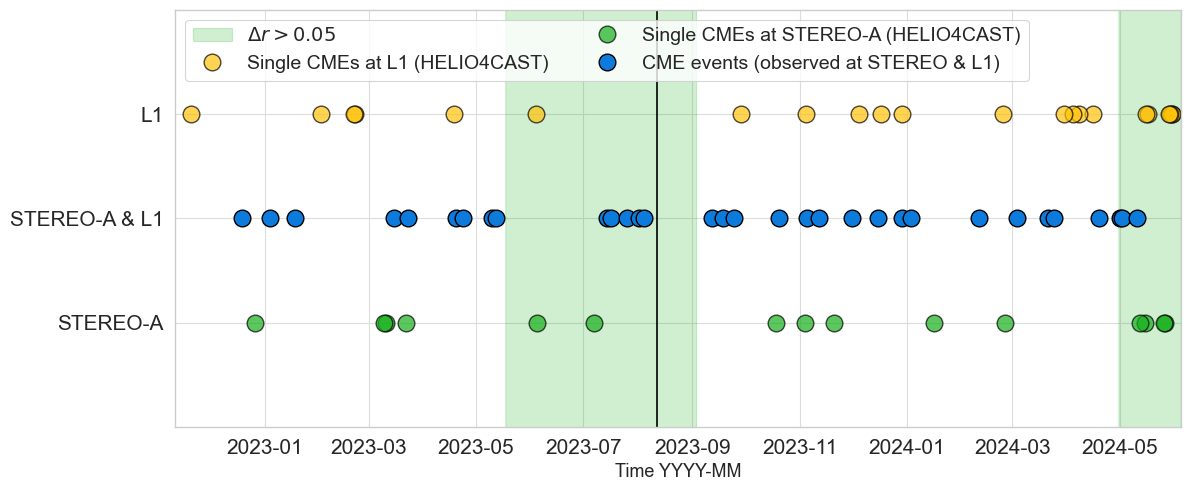

In [11]:

fig, ax1 = plt.subplots(figsize=(12,5), dpi=100)#, gridspec_kw={'height_ratios': [2, 1]})

ax1.fill_between(sc_input_heeq.time, -10, 10, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$')  
ax1.plot(ic_events_wind[mask_single==False], np.ones(len(ic_events_wind[mask_single==False])), marker='o', ms=12, alpha=0.7, color=c2, mec=c0, ls='',label='Single CMEs at L1 (HELIO4CAST)')
ax1.plot(ic_events_sta[mask_single_sta==False], -1.*np.ones(len(ic_events_sta[mask_single_sta==False])), marker='o', ms=12, color=c4, mec=c0, alpha=0.7, ls='', label='Single CMEs at STEREO-A (HELIO4CAST)')
ax1.plot(times.l1_start, np.zeros(len(times.l1_start)), marker='o', ms=12, color=c3, mec=c0, ls='', label='CME events (observed at STEREO & L1)')
ax1.plot([datetime(2023,8,12),datetime(2023,8,12)], [-10,10], 'k-')
ax1.set_ylim(-2,2)
ax1.tick_params('x', labelsize=15)
ax1.set_xlabel('Time YYYY-MM',fontsize=13)
ax1.set_xlim(datetime(2022,11,11), datetime(2024,6,5))
ax1.legend(loc='upper left', ncols=2, fontsize=14)
#t_float = date2num(sc_input.time)
#ax3 = ax1.twiny()
#ticks = ax1.get_xticks()
#ax3.set_xticks(mdates.num2date(ticks))
#ax3.grid(False)
#lon_interp = np.interp(ticks, t_float, sc_input_heeq.lon)
#ax3.set_xticklabels([f"{L:.0f}°" for L in lon_interp], color=c0, fontsize=14)
#ax3.set_xlabel('STEREO-A Longitude [°, HEEQ]', color=c0,fontsize=13)  # we already handled the x-label with ax1
#ax3.tick_params(axis='x', length=0)
#ax3.set_xlim(ax1.get_xlim())
#plt.yticks(['L1', 'STEREO-A & L1', 'STEREO-A'])
labels=['L1', 'STEREO-A & L1', 'STEREO-A']
plt.yticks([1, 0, -1], labels, fontsize=15)
plt.tight_layout()
#plt.savefig('HELIO4CAST_CME_events.pdf')

## Calculate RMSE between observed and modeled indices
1. for hits (26 GS events given in Table 2 in paper)
2. for missed events in target region

In [12]:
def calc_rmse(in1, in2):

    rmse = np.sqrt(((in1.symh - in2['symh']) ** 2).mean())
    
    return rmse

event_gs_int = []
event_gs_mod = []
time_gs_int = []
time_gs_mod = []
rmse_true_pos_int = []
rmse_true_pos_mod = []
for i in range(len(times_gs)):
    in1_cut = omni_input[(omni_input.time>=times_gs.start_time[i]) & (omni_input.time<=times_gs.end_time[i])]
    in2_cut = data1[(data1['time']>=times_gs.start_time[i]) & (data1['time']<=times_gs.end_time[i])]
    rmse_gs = calc_rmse(in1_cut, in2_cut)
    if np.min(in1_cut.symh) <= -100.: 
        event_gs_int.append(times_gs.gs_event[i])
        time_gs_int.append(times_gs.start_time[i])
        rmse_true_pos_int.append(rmse_gs)
    else:
        event_gs_mod.append(times_gs.gs_event[i])
        time_gs_mod.append(times_gs.start_time[i])
        rmse_true_pos_mod.append(rmse_gs)
    
print(rmse_true_pos_int, len(rmse_true_pos_int))

[41.21149415670024, 47.66994785097447, 76.04574280433232, 36.348115830435106, 21.992310444554487, 29.643136501694066, 60.88505872023053, 54.37465707534118, 29.91000632202395, 50.15763745375089, 31.993054101367356, 37.23514783187835, 51.240191826171795, 20.833542567720652] 14


In [13]:
rmse_misses = []
for i in range(len(times_gs_misses)):
    in1_cut = omni_input[(omni_input.time>=times_gs_misses.start_time[i]) & (omni_input.time<=times_gs_misses.end_time[i])]
    in2_cut = data1[(data1['time']>=times_gs_misses.start_time[i]) & (data1['time']<=times_gs_misses.end_time[i])]
    rmse_gs_misses = calc_rmse(in1_cut, in2_cut)
    rmse_misses.append(rmse_gs_misses)
    
print(np.round(rmse_misses,0))

[32. 12. 15.]


In [14]:
#Shift L1 arrival times to Earth to get time difference between Earth & STEREO-A

[delta_t_l1, delta_t_mean_l1, delta_t_std_l1, delta_t_sc_455, delta_t_mean_sc_455, delta_t_std_sc_455] = pickle.load(open(data_path+'mean_time_shift_and_sigma_beacon_plasma_new.p', 'rb'))


nan_mask = np.isnan(delta_t_mean_l1)
l1_shifted = []
print(len(l1_shifted))
print(len(delta_t_mean_l1))

for i in range(len(l1_input.time)):
    if nan_mask[i] == False:
    #print(delta_t_mean_l1[i])
        l1_shifted_ind = l1_input[i].time+timedelta(seconds=delta_t_mean_l1[i].astype(float))
        l1_shifted.append(l1_shifted_ind)
    else:
        l1_shifted.append(np.nan)

#l1_shifted = [l1_input[i].time+timedelta(seconds=delta_t_mean_l1[i].astype(float)) for i in range(len(delta_t_mean_l1))]
print(l1_shifted[0])

times_earth_start = [l1_shifted[np.where(l1_input.time == i)[0][0]] for i in times.l1_start]
times_earth_end = [l1_shifted[np.where(l1_input.time == i)[0][0]] for i in times.l1_end]

0
823681
2022-11-11 01:04:16.566406


### Perform some statistics on hits, misses and false alarms

In [15]:
mask = np.isin(indices_dst_omni, indices_obs_omni)
indices_omni_miss = indices_dst_omni[mask==False]
indices_omni_hit = indices_dst_omni[mask==True]
time_hit_omni = omni_input['time'][indices_omni_hit]
symh_hit_omni = omni_input['symh'][indices_omni_hit]
time_miss_omni = omni_input['time'][indices_omni_miss]
symh_miss_omni = omni_input['symh'][indices_omni_miss]

mask_l1 = np.isin(indices_dst_l1, indices_l1_sta)
indices_l1_miss = indices_dst_l1[mask_l1==False]
indices_l1_hit = indices_dst_l1[mask_l1==True]
time_storm_l1 = data_l1['time'][indices_dst_l1]
symh_storm_l1 = data_l1['symh'][indices_dst_l1]
time_hit_l1 = data_l1['time'][indices_l1_hit]
symh_hit_l1 = data_l1['symh'][indices_l1_hit]
time_miss_l1 = data_l1['time'][indices_l1_miss]

mask_l1_obs = np.isin(indices_dst_l1, indices_obs_l1)
indices_omni_miss_l1 = indices_dst_l1[mask_l1_obs==False]
indices_omni_hit_l1 = indices_dst_l1[mask_l1_obs==True]
time_hit_omni_l1 = data_l1['time'][indices_omni_hit_l1]
symh_hit_omni_l1 = data_l1['symh'][indices_omni_hit_l1]
time_miss_omni_l1 = data_l1['time'][indices_omni_miss_l1]
symh_miss_omni_l1 = data_l1['symh'][indices_omni_miss_l1]

mask_obs_l1 = np.isin(indices_dst_omni, indices_obs_omni_l1)
indices_omni_miss_obs_l1 = indices_dst_omni[mask_obs_l1==False]
indices_omni_hit_obs_l1 = indices_dst_omni[mask_obs_l1==True]
time_hit_omni_obs_l1 = omni_input['time'][indices_omni_hit_obs_l1]
symh_hit_omni_obs_l1 = omni_input['symh'][indices_omni_hit_obs_l1]
time_miss_omni_obs_l1 = omni_input['time'][indices_omni_miss_obs_l1]
symh_miss_omni_obs_l1 = omni_input['symh'][indices_omni_miss_obs_l1]

time_storm_omni_all = omni_input.time[indices_dst_omni]
time_storm_sta_all = data1['time'][indices_dst_sta]
time_storm_l1_all = data_l1['time'][indices_dst_l1]

symh_storm_omni_all = omni_input.symh[indices_dst_omni]
symh_storm_sta_all = data1['symh'][indices_dst_sta]
symh_storm_l1_all = data_l1['symh'][indices_dst_l1]

mask_alarm = np.isin(indices_dst_sta, indices_obs_sta)
indices_false_alarm = indices_dst_sta[mask_alarm==False]
indices_sta_hit = indices_dst_sta[mask_alarm==True]
time_false_alarm = data1['time'][indices_false_alarm] 
symh_false_alarm = data1['symh'][indices_false_alarm]
time_hit_sta = data1['time'][indices_obs_sta]
symh_hit_sta = data1['symh'][indices_obs_sta]

mask_alarm_l1 = np.isin(indices_dst_l1, indices_obs_l1)
indices_false_alarm_l1 = indices_dst_l1[mask_alarm_l1==False]
time_false_alarm_l1_all = data_l1['time'][indices_false_alarm_l1] 
symh_false_alarm_l1_all = data_l1['symh'][indices_false_alarm_l1]

mask_alarm_sta_l1 = np.isin(indices_false_alarm, indices_sta_l1)
indices_false_alarm_sta_l1 = indices_false_alarm[mask_alarm_sta_l1==True]
time_false_alarm_sta_l1 = data1['time'][indices_false_alarm_sta_l1]
symh_false_alarm_sta_l1 = data1['symh'][indices_false_alarm_sta_l1]

mask_alarm_l1_sta = np.isin(indices_false_alarm_l1, indices_l1_sta)
indices_false_alarm_l1_sta = indices_false_alarm_l1[mask_alarm_l1_sta==False]

indices_false_alarm_l1_sta = indices_false_alarm_l1[mask_alarm_l1_sta==True]
time_false_alarm_l1_sta = data_l1['time'][indices_false_alarm_l1_sta]
symh_false_alarm_l1_sta = data_l1['symh'][indices_false_alarm_l1_sta]

time_false_alarm_l1 = data_l1['time'][indices_false_alarm_l1_sta]
symh_false_alarm_l1 = data_l1['symh'][indices_false_alarm_l1_sta]

print('done')

done


In [16]:
#sanity check
print('identified geomagnetic storms from L1 data: ', len(indices_obs_l1))

print('identified geomagnetic storms from L1 data: ', len(time_hit_omni_obs_l1))
#print(time_hit_omni_obs_l1)

identified geomagnetic storms from L1 data:  35
identified geomagnetic storms from L1 data:  35


In [17]:
mask_both_hit = np.isin(indices_sta_hit, indices_sta_l1)
indices = indices_sta_hit[mask_both_hit==True]
#print(data1['time'][indices])
print('# same false alarms at STA & L1: ', len(indices_l1_sta))
#print(time_false_alarm_sta_l1, symh_false_alarm_sta_l1)
print('# false alarms at L1: ', len(time_false_alarm_l1_all))
#print(time_false_alarm_l1_all)
#print(time_false_alarm_l1)

# same false alarms at STA & L1:  2
# false alarms at L1:  15


In [18]:
symh_miss_omni_mod = symh_miss_omni[symh_miss_omni>-100]


time_hit_omni_100 = time_hit_omni[symh_hit_omni<=-100]
symh_miss_l1_100 = symh_miss_omni_obs_l1[symh_miss_omni_obs_l1>-100]
symh_hit_omni_100 = symh_hit_omni[symh_hit_omni<=-100]
symh_miss_omni_100 = symh_miss_omni[symh_miss_omni<=-100]
time_miss_omni_100 = time_miss_omni[symh_miss_omni<=-100]
print('Min. SYM-H of missed intense geomagnetic storms: ', symh_miss_omni_100)
print('Min. SYM-H of hitted intense geomagnetic storms: ', np.sort(symh_hit_omni[symh_hit_omni<=-100.]))
print('Time of missed intense geomagnetic storms: ', time_miss_omni_100)

print('percent missed moderate/all missed storms STA: ', round(len(symh_miss_omni_mod)/len(symh_miss_omni)*100,0))

print('percent missed moderate/all missed storms L1: ', round(len(symh_miss_l1_100)/len(symh_miss_omni_obs_l1)*100,0))

print('false alarms STA: ', len(time_false_alarm)) 

#print((len(time_miss_omni)-len(time_miss_omni_100))/len(time_miss_omni))

Min. SYM-H of missed intense geomagnetic storms:  [-108. -106.]
Min. SYM-H of hitted intense geomagnetic storms:  [-518. -233. -189. -174. -170. -161. -139. -136. -128. -109. -108. -108.
 -103. -100.]
Time of missed intense geomagnetic storms:  [datetime.datetime(2023, 5, 6, 5, 32)
 datetime.datetime(2024, 5, 16, 9, 37)]
percent missed moderate/all missed storms STA:  90.0
percent missed moderate/all missed storms L1:  92.0
false alarms STA:  9


In [19]:
for i in range(len(time_hit_omni_100)):
    print(time_hit_omni_100[i], symh_hit_omni_100[i])

2023-02-27 12:13:00 -161.0
2023-03-24 05:22:00 -170.0
2023-04-24 04:03:00 -233.0
2023-08-05 05:49:00 -103.0
2023-10-21 07:28:00 -108.0
2023-11-05 16:55:00 -189.0
2023-11-25 19:11:00 -109.0
2023-12-01 13:30:00 -136.0
2024-03-03 18:06:00 -128.0
2024-03-24 16:21:00 -174.0
2024-04-19 19:21:00 -139.0
2024-05-02 19:43:00 -100.0
2024-05-11 02:14:00 -518.0
2024-05-17 23:05:00 -108.0


In [20]:
#omni_symh_all = omni_input.symh[indices_dst_omni]
#print(len(omni_symh_all[omni_symh_all>-100.]))

### Identify geomagnetic storm events that are associated with a CME
1. Number of obs. geomagnetic storms related to CME from HELIO4CAST ICME-CAT
2. Number of obs. geomagnetic storms related to one of 32 CME events investigated in paper
3. Number of modeled geomagnetic storms related to one of 32 CME events investigated in paper (from STEREO-A data)
4. Number of modeled geomagnetic storms related to one of 32 CME events investigated in paper (from L1 data)

In [21]:
gs_with_cme = []
index_cme = []

for i in range(len(time_storm_omni_all)):
    for j in range(len(ic)):
        if ic.icme_start_time.iloc[j]-timedelta(hours=5)<= time_storm_omni_all[i] <= ic.mo_end_time.iloc[j]+timedelta(hours=5):
            if time_storm_omni_all[i] not in gs_with_cme:
                gs_with_cme.append(time_storm_omni_all[i])
                index_cme.append(i)
#print(time_storm_omni_all)
print('Geomagnetic storms associated with CME: ', len(gs_with_cme))
print('Geomagnetic storms not associated with CME: ', len(time_storm_omni_all)-len(gs_with_cme))
print('Strength of geomagnetic storms with CME: ', symh_storm_omni_all[index_cme])
print('Time of geomagnetic storms with CME: ', time_storm_omni_all[index_cme])
time_storm_cme_omni = time_storm_omni_all[index_cme]
symh_storm_cme_omni = symh_storm_omni_all[index_cme]

#print(time_storm_omni_all)

Geomagnetic storms associated with CME:  28
Geomagnetic storms not associated with CME:  19
Strength of geomagnetic storms with CME:  [ -73.  -74.  -64.  -53.  -60. -170. -233.  -60.  -67. -103.  -84.  -96.
  -73. -108.  -67. -189. -136. -128.  -81. -174.  -77. -139. -100.  -66.
 -518. -106. -108.  -56.]
Time of geomagnetic storms with CME:  [datetime.datetime(2022, 12, 27, 8, 11)
 datetime.datetime(2023, 1, 4, 9, 4) datetime.datetime(2023, 2, 21, 12, 4)
 datetime.datetime(2023, 3, 9, 9, 5)
 datetime.datetime(2023, 3, 15, 22, 54)
 datetime.datetime(2023, 3, 24, 5, 22)
 datetime.datetime(2023, 4, 24, 4, 3)
 datetime.datetime(2023, 7, 16, 23, 41)
 datetime.datetime(2023, 7, 26, 7, 54)
 datetime.datetime(2023, 8, 5, 5, 49)
 datetime.datetime(2023, 9, 12, 22, 3)
 datetime.datetime(2023, 9, 19, 2, 50)
 datetime.datetime(2023, 9, 25, 2, 23)
 datetime.datetime(2023, 10, 21, 7, 28)
 datetime.datetime(2023, 10, 29, 5, 20)
 datetime.datetime(2023, 11, 5, 16, 55)
 datetime.datetime(2023, 12, 1, 1

In [22]:
gs_with_cme = []
index_cme = []
index_cme_cme = []
time_cme_gs = []
time_cme_gs_new = []
time_earth = []
index_cme_gs = []
missed_cme_gs =[]

for i in range(len(time_storm_omni_all)):
    #time_storm_omni_all[i]
    for j in range(len(times_earth_start)):
        if times_earth_start[j]-timedelta(hours=0)<= time_storm_omni_all[i] <= times_earth_end[j]+timedelta(hours=10):
            if time_storm_omni_all[i] not in gs_with_cme:
                gs_with_cme.append(time_storm_omni_all[i])
                index_cme.append(i)
                index_cme_cme.append(j)
                time_earth.append(times_earth_start[j])
                for k in range(len(times_gs.start_time)):
                    #print(times_gs.start_time[k])
                    if times_gs.start_time[k]<= time_storm_omni_all[i] <= times_gs.end_time[k]:
                        time_cme_gs.append(times_gs.start_time[k])
                        time_cme_gs_new.append(time_storm_omni_all[i])
                        index_cme_gs.append(k)
    


                
#print(time_storm_omni_all)
print('Geomagnetic storms associated with CME, all observed: ', len(gs_with_cme))
print('Geomagnetic storms not associated with CME: ', len(time_storm_omni_all)-len(gs_with_cme))
print('Strength of geomagnetic storms with CME: ', symh_storm_omni_all[index_cme])
print('Time of geomagnetic storms with CME: ', time_storm_omni_all[index_cme])

print(index_cme, index_cme_cme)
print('   ')

#print(time_storm_omni_all[index_cme][time_storm_omni_all[index_cme]<=datetime(2023,8,12)])
print('GS with CME east: ', len(time_storm_omni_all[index_cme][time_storm_omni_all[index_cme]<=datetime(2023,8,12)]))
print('GS with CME west: ', len(time_storm_omni_all[index_cme][time_storm_omni_all[index_cme]>=datetime(2023,8,12)]))
time_storm_cme_omni = time_storm_omni_all[index_cme]
symh_storm_cme_omni = symh_storm_omni_all[index_cme]
#print(time_earth)

#print(time_cme_gs)
mask_cme= np.isin(gs_with_cme,time_cme_gs_new)
#print(mask_cme)
gs_with_cme=np.array(gs_with_cme)
print('Geomagnetic storms associated with CME but not modeled with STEREO-A: ', gs_with_cme[mask_cme==False])
#print(len(time_cme_gs))



gs_with_cme_tp = []
index_cme_tp = []
time_cme_gs_tp = []
time_cme_gs_new_tp = []
index_cme_gs_tp = []
missed_cme_gs_tp =[]

for i in range(len(time_hit_omni)):
    #time_storm_omni_all[i]
    for j in range(len(times_earth_start)):
        if times_earth_start[j]-timedelta(hours=5)<= time_hit_omni[i] <= times_earth_end[j]+timedelta(hours=5):
            #if time_storm_omni_all[i] not in gs_with_cme:
            gs_with_cme_tp.append(time_hit_omni[i])
            index_cme_tp.append(i)
            for k in range(len(times_gs.start_time)):
                #print(times_gs.start_time[k])
                if times_gs.start_time[k]<= time_hit_omni[i] <= times_gs.end_time[k]:
                    time_cme_gs_tp.append(times_gs.start_time[k])
                    time_cme_gs_new_tp.append(time_storm_omni_all[i])
                    index_cme_gs_tp.append(k)

print('Geomagnetic storms associated with CME (only true positives, 26 events): ', len(gs_with_cme_tp))
print('Time of geomagnetic storms with CME (only true positives, 26 events): ', time_hit_omni[index_cme_tp])



Geomagnetic storms associated with CME, all observed:  20
Geomagnetic storms not associated with CME:  27
Strength of geomagnetic storms with CME:  [ -74.  -60. -170. -233.  -60.  -67. -103.  -84.  -96.  -73.  -61. -108.
 -189. -136. -128.  -81. -174. -139. -100. -518.]
Time of geomagnetic storms with CME:  [datetime.datetime(2023, 1, 4, 9, 4)
 datetime.datetime(2023, 3, 15, 22, 54)
 datetime.datetime(2023, 3, 24, 5, 22)
 datetime.datetime(2023, 4, 24, 4, 3)
 datetime.datetime(2023, 7, 16, 23, 41)
 datetime.datetime(2023, 7, 26, 7, 54)
 datetime.datetime(2023, 8, 5, 5, 49)
 datetime.datetime(2023, 9, 12, 22, 3)
 datetime.datetime(2023, 9, 19, 2, 50)
 datetime.datetime(2023, 9, 25, 2, 23)
 datetime.datetime(2023, 9, 26, 20, 12)
 datetime.datetime(2023, 10, 21, 7, 28)
 datetime.datetime(2023, 11, 5, 16, 55)
 datetime.datetime(2023, 12, 1, 13, 30)
 datetime.datetime(2024, 3, 3, 18, 6)
 datetime.datetime(2024, 3, 21, 19, 36)
 datetime.datetime(2024, 3, 24, 16, 21)
 datetime.datetime(2024, 

In [23]:
mask_cme = np.isin(times_earth_start, time_earth)
times_earth_start=np.array(times_earth_start)
no_cme = times_earth_start[mask_cme==False]
#print(no_cme)
#print(len(no_cme))

In [24]:
#print(time_hit_omni)
#print(time_hit_omni[index_cme_tp])

In [25]:
index_cme_sta = []
gs_with_cme_sta = []
cme_miss = []
index_cme_sta_cme = []

for i in range(len(time_hit_sta)):
    #print(time_storm_sta_all[i])
    for j in range(len(times_earth_start)):
        #if times_earth_start[j]-timedelta(hours=10)<= time_storm_sta_all[i] <= times_earth_end[j]+timedelta(hours=10):
        if times_earth_start[j]-timedelta(hours=10)<= time_hit_sta[i] <= times_earth_end[j]+timedelta(hours=10):
           # if time_hit_omni[i] in time_hit_omni[index_cme_tp]:
        #if time_storm_omni_all[i] not in gs_with_cme_sta:
            gs_with_cme_sta.append(time_hit_sta[i])
            index_cme_sta.append(i)
            index_cme_sta_cme.append(j)

                
print('Geomagnetic storms associated with CME (STA, CME events): ', len(gs_with_cme_sta))  
#print('Time of geomagnetic storms with CME: ', time_storm_sta_all[index_cme_sta])
#print('Modelled strength of geomagnetic storms with CME: ', symh_storm_sta_all[index_cme_sta])
print('Time of geomagnetic storms with CME: ', time_hit_sta[index_cme_sta])
print('Modelled strength of geomagnetic storms with CME: ', symh_hit_sta[index_cme_sta])

gs_with_cme_all = []
gs_false_alarm = []
for i in range(len(time_storm_sta_all)):
    #print(time_storm_sta_all[i])
    for j in range(len(times_earth_start)):
        if times_earth_start[j]-timedelta(hours=10)<= time_storm_sta_all[i] <= times_earth_end[j]+timedelta(hours=10):
            if time_storm_sta_all[i] not in gs_with_cme_sta:
                gs_with_cme_all.append(time_storm_sta_all[i])
            #index_cme_sta.append(i)
           
            
print(gs_with_cme_all)


Geomagnetic storms associated with CME (STA, CME events):  16
Time of geomagnetic storms with CME:  [datetime.datetime(2023, 3, 24, 10, 1)
 datetime.datetime(2023, 4, 24, 11, 31)
 datetime.datetime(2023, 7, 26, 10, 33)
 datetime.datetime(2023, 8, 5, 13, 0)
 datetime.datetime(2023, 9, 12, 23, 27)
 datetime.datetime(2023, 9, 19, 16, 15)
 datetime.datetime(2023, 9, 26, 8, 57)
 datetime.datetime(2023, 10, 21, 6, 19)
 datetime.datetime(2023, 11, 5, 17, 54)
 datetime.datetime(2023, 12, 1, 20, 37)
 datetime.datetime(2024, 3, 3, 16, 0)
 datetime.datetime(2024, 3, 22, 1, 19)
 datetime.datetime(2024, 3, 24, 23, 41)
 datetime.datetime(2024, 4, 20, 4, 53)
 datetime.datetime(2024, 5, 3, 0, 25)
 datetime.datetime(2024, 5, 10, 23, 12)]
Modelled strength of geomagnetic storms with CME:  [-163.90700221 -260.38329997  -91.06150044 -113.58333403 -104.10771809
 -172.01477848 -107.13838559  -98.66909309 -137.27218207 -188.25417638
  -58.99785826  -59.37903    -153.46283391 -119.8788535  -141.72491493
 -490

In [27]:
mask_hit_cme = np.isin(index_cme_cme, index_cme_sta_cme)
#print(mask_hit_cme)

#print(np.array(times_earth_start)[np.array(index_cme_cme)[mask_hit_cme==False]])
#
for i in range(len(mask_hit_cme)):
    if mask_hit_cme[i] == True:
        print('CME event: ', index_cme_cme[i], '& hit')
    else:
        print('CME events: ', index_cme_cme[i], '& miss')


CME events:  1 & miss
CME events:  3 & miss
CME event:  4 & hit
CME event:  6 & hit
CME events:  9 & miss
CME event:  11 & hit
CME event:  13 & hit
CME event:  14 & hit
CME event:  15 & hit
CME event:  16 & hit
CME event:  16 & hit
CME event:  17 & hit
CME event:  18 & hit
CME event:  20 & hit
CME event:  25 & hit
CME event:  26 & hit
CME event:  27 & hit
CME event:  28 & hit
CME event:  30 & hit
CME event:  31 & hit


In [28]:
index_cme_l1 = []
gs_with_cme_l1 = []
for i in range(len(time_hit_omni_l1)):
    for j in range(len(times_earth_start)):
        if times_earth_start[j]-timedelta(hours=5)<= time_hit_omni_l1[i] <= times_earth_end[j]+timedelta(hours=5):
            #if time_storm_omni_all[i] not in gs_with_cme_l1:
            gs_with_cme_l1.append(time_hit_omni_l1[i])
            index_cme_l1.append(i)
                
print('Geomagnetic storms associated with CME, L1: ', len(gs_with_cme_l1))              
print('Time of geomagnetic storms with CME: ', time_hit_omni_obs_l1[index_cme_l1])

Geomagnetic storms associated with CME, L1:  19
Time of geomagnetic storms with CME:  [datetime.datetime(2023, 1, 4, 9, 4)
 datetime.datetime(2023, 3, 15, 22, 54)
 datetime.datetime(2023, 3, 24, 5, 22)
 datetime.datetime(2023, 4, 24, 4, 3)
 datetime.datetime(2023, 7, 16, 23, 41)
 datetime.datetime(2023, 7, 26, 7, 54)
 datetime.datetime(2023, 8, 5, 5, 49)
 datetime.datetime(2023, 9, 12, 22, 3)
 datetime.datetime(2023, 9, 19, 2, 50)
 datetime.datetime(2023, 9, 26, 20, 12)
 datetime.datetime(2023, 10, 21, 7, 28)
 datetime.datetime(2023, 11, 5, 16, 55)
 datetime.datetime(2023, 12, 1, 13, 30)
 datetime.datetime(2024, 3, 3, 18, 6)
 datetime.datetime(2024, 3, 21, 19, 36)
 datetime.datetime(2024, 3, 24, 16, 21)
 datetime.datetime(2024, 4, 19, 19, 21)
 datetime.datetime(2024, 5, 2, 19, 43)
 datetime.datetime(2024, 5, 11, 2, 14)]


In [30]:
#statistics for missed storms at beginning of time period up to 15 march, 2023

print(round(8/len(time_miss_omni)*100,0))
#print(len(time_hit_omni))
print((omni_input.time[-1]-omni_input.time[0]))
print(datetime(2023, 3, 15, 22, 54)-omni_input.time[0])

print('percentage of time range till March 15: ', round(125/572*100,0))

38.0
572 days, 0:00:00
124 days, 22:54:00
percentage of time range till March 15:  22.0


In [31]:
print('percent of false alarms, moderate storms STA: ', np.round(len(time_false_alarm[symh_false_alarm>-100.])/len(symh_false_alarm)*100,1))
print('percent of false alarms, moderate storms L1: ', np.round(len(time_false_alarm_l1_all[symh_false_alarm_l1_all>-100.])/len(symh_false_alarm_l1_all)*100,1))

percent of false alarms, moderate storms STA:  88.9
percent of false alarms, moderate storms L1:  86.7


In [32]:
print(len(time_hit_sta), len(time_hit_omni))

time_intense_events_omni = time_hit_omni[symh_hit_omni<=-100.]
time_intense_events_sta = time_hit_omni[symh_hit_sta<=-100.]

time_intense_both = []
for i in time_intense_events_omni:
    for j in time_intense_events_sta:
        if i == j:
            print(i)
            time_intense_both.append(i)
            
symh_intense_both=[]
for i in range(len(time_hit_omni)):
    for j in time_intense_both:
        if time_hit_omni[i] == j:
            symh_intense_both.append(symh_hit_omni[i])

print('SYM-H values for intense events (intense obs. and at STEREO-A): ', symh_intense_both)
print('Time of min(SYM-H) for intense events (intense obs. and at STEREO-A): ', time_intense_both)
print('Numboer of intense events that are also modeled as intense storms: ', len(symh_intense_both), len(time_intense_both))

26 26
2023-02-27 12:13:00
2023-03-24 05:22:00
2023-04-24 04:03:00
2023-08-05 05:49:00
2023-11-05 16:55:00
2023-11-25 19:11:00
2023-12-01 13:30:00
2024-03-24 16:21:00
2024-04-19 19:21:00
2024-05-02 19:43:00
2024-05-11 02:14:00
SYM-H values for intense events (intense obs. and at STEREO-A):  [-161.0, -170.0, -233.0, -103.0, -189.0, -109.0, -136.0, -174.0, -139.0, -100.0, -518.0]
Time of min(SYM-H) for intense events (intense obs. and at STEREO-A):  [datetime.datetime(2023, 2, 27, 12, 13), datetime.datetime(2023, 3, 24, 5, 22), datetime.datetime(2023, 4, 24, 4, 3), datetime.datetime(2023, 8, 5, 5, 49), datetime.datetime(2023, 11, 5, 16, 55), datetime.datetime(2023, 11, 25, 19, 11), datetime.datetime(2023, 12, 1, 13, 30), datetime.datetime(2024, 3, 24, 16, 21), datetime.datetime(2024, 4, 19, 19, 21), datetime.datetime(2024, 5, 2, 19, 43), datetime.datetime(2024, 5, 11, 2, 14)]
Numboer of intense events that are also modeled as intense storms:  11 11


### Plot Figure 5 in paper

In [34]:
sc_input_heeq = pickle.load(open(data_path+'sta_science_HEEQ_20221111_20240604.p', 'rb'))

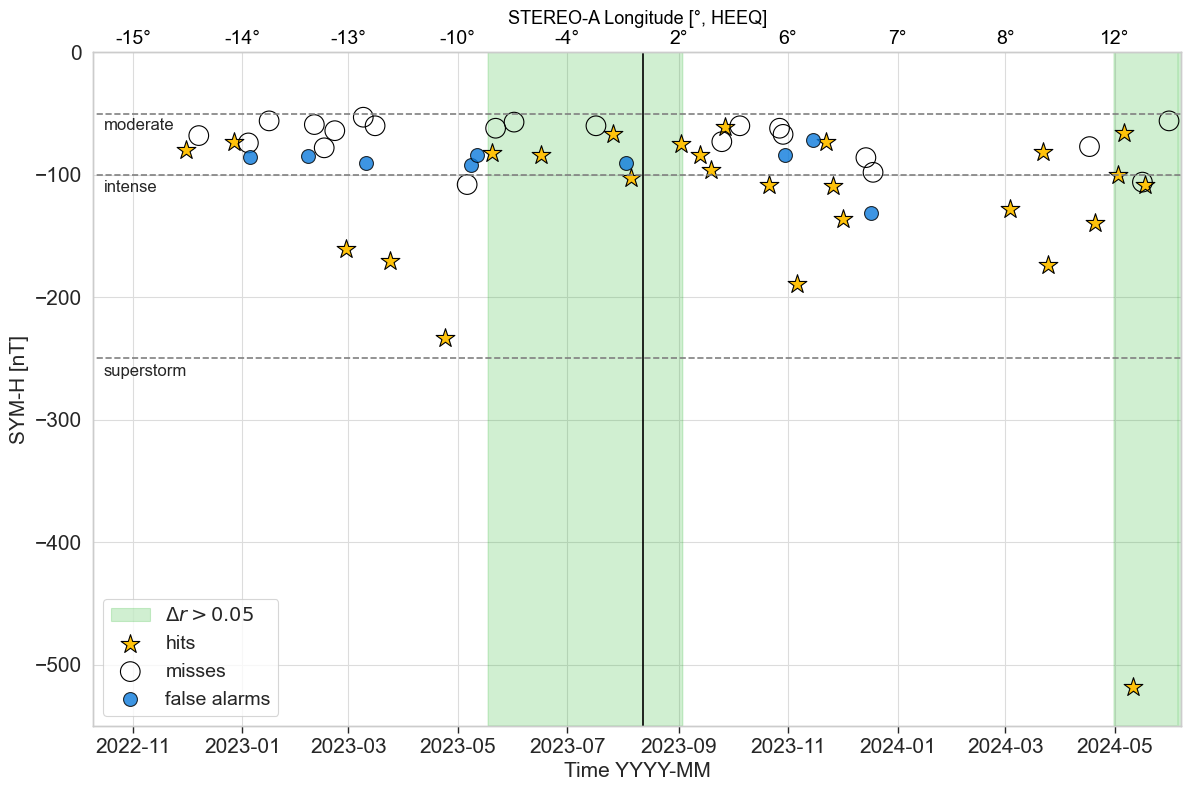

In [35]:
fig, ax1 = plt.subplots(figsize=(12,8), dpi=100)#, gridspec_kw={'height_ratios': [2, 1]})


ax1.fill_between(sc_input_heeq.time, -550, 0, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$') 
ax1.fill_between([sc_input_heeq.time[-1], datetime(2024,6,15)], -550, 0, color=c4, alpha=0.2) 
ax1.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-50,-50], color='gray', ls='--')
ax1.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-100,-100], color='gray', ls='--')
#ax1.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-200,-200], color='gray', ls='--')
ax1.plot([sc_input.time[0]-timedelta(days=40),sc_input.time[-1]+timedelta(days=20)], [-250,-250], color='gray', ls='--')
#ax1.scatter(time_hit_omni_obs_l1 , symh_hit_omni_obs_l1 , marker='o', edgecolor='black', s=200, color=c2, alpha=0.8, label='true positive L1')
#ax1.scatter(time_miss_omni_obs_l1 , symh_miss_omni_obs_l1 , marker='o', edgecolor='black', s=200, color=c0, alpha=0.6, label='false negative L1')
ax1.scatter(time_hit_omni, symh_hit_omni, marker='*', s=200, color=c2, edgecolor='black', label='hits')
#ax1.scatter(time_miss_omni, symh_miss_omni, marker='x', s=100, edgecolor='black', color=c3, label='misses')
ax1.scatter(time_miss_omni, symh_miss_omni, marker='o', s=200, edgecolor='black', facecolors='none', label='misses')
ax1.scatter(time_false_alarm, symh_false_alarm, marker='o', edgecolor='black', s=100, color=c3, alpha=0.8, label='false alarms')
ax1.plot([datetime(2023,8,12),datetime(2023,8,12)], [-550,0], 'k-')
ax1.set_ylim(-550,0)
ax1.set_xlim(datetime(2022,10,10), datetime(2024,6,7))
ax1.set_ylabel('SYM-H [nT]',fontsize=15)
ax1.tick_params('x', labelsize=15)
ax1.tick_params('y', labelsize=15)
ax1.legend(loc='lower left', fontsize=14)
t_float = date2num(sc_input.time)
ax3 = ax1.twiny()
ticks = ax1.get_xticks()
ax3.set_xticks(mdates.num2date(ticks))
ax3.grid(False)
lon_interp = np.interp(ticks, t_float, sc_input_heeq.lon)
ax3.set_xticklabels([f"{L:.0f}°" for L in lon_interp], color=c0, fontsize=14)
ax3.set_xlabel('STEREO-A Longitude [°, HEEQ]', color=c0,fontsize=13)  # we already handled the x-label with ax1
ax3.tick_params(axis='x', length=0)
ax3.set_xlim(ax1.get_xlim())

ax1.set_xlabel('Time YYYY-MM',fontsize=15)
#ax2.set_ylabel('SYM-H [nT]',fontsize=15)
#ax2.tick_params('x', labelsize=15)
#ax2.tick_params('y', labelsize=15)
#ax2.legend(loc='lower left', fontsize=14)

plt.figtext(0.09,0.832, 'moderate', fontsize=12)
plt.figtext(0.09,0.755, 'intense', fontsize=12)
plt.figtext(0.09,0.525, 'superstorm', fontsize=12)
#plt.figtext(0.01,0.33, 'b)', fontsize=18)
plt.tight_layout()
#plt.savefig('hits_misses_false_alarms.pdf')


In [36]:
time_diff = np.array([(i-j).total_seconds()/3600. for i,j in zip(time_hit_omni, time_hit_sta)])
#time_diff = np.array([(i-j).total_seconds()/3600. for i,j in zip(time_hit_sta, time_hit_omni)])
#time_diff = np.array([(i-j).total_seconds()/3600. for i,j in zip(time_hit_l1, time_hit_sta)])
print('Bias in time Obs. - STEREO-A: ', np.mean(time_diff))
symh_diff = symh_hit_sta-symh_hit_omni

time_diff_l1 = np.array([(i-j).total_seconds()/3600. for i,j in zip(time_hit_omni_obs_l1, time_hit_omni_l1)])
print('Bias in time Obs. - L1: ', np.mean(time_diff_l1)*60.)
#print(len(time_diff_l1))
symh_diff_l1 = symh_hit_omni_l1-symh_hit_omni_obs_l1

#plt.figure(figsize=(12,8))
#plt.plot(time_hit_omni_l1, time_diff_l1, marker='*', ms=12, color=c2, ls=' ')

#for i in range(len(time_hit_omni_l1)):
#    print(time_hit_omni_l1[i], time_diff_l1[i])

Bias in time Obs. - STEREO-A:  -2.398717948717948
Bias in time Obs. - L1:  -50.571428571428584


In [37]:
print('percentage of events predicted later than observed: ', np.round(len(time_diff[time_diff<0])/len(time_diff)*100,0))
#print(time_diff)

print('When does modeled time of min(SYM-H) deviate the most from observed time?: ', time_hit_omni[np.abs(time_diff)==np.max(np.abs(time_diff))])
print(np.max(time_diff))

percentage of events predicted later than observed:  73.0
When does modeled time of min(SYM-H) deviate the most from observed time?:  [datetime.datetime(2023, 6, 16, 9, 32)]
19.35


### Calculate RMSE for Figure 6 and create Figure 6

In [38]:
def calc_rmse(in1, in2):

    rmse = np.sqrt(((in1.symh - in2['symh']) ** 2).mean())
    
    return rmse

event_gs_int = []
event_gs_mod = []
time_gs_int = []
time_cme_gs_int = []
time_gs_mod = []
rmse_true_pos_int = []
rmse_true_pos_mod = []
rmse_all = []
index_int = []
index_mod = []
for i in range(len(times_gs)):
    in1_cut = omni_input[(omni_input.time>=times_gs.start_time[i]) & (omni_input.time<=times_gs.end_time[i])]
    in2 = copy.deepcopy(data1) 
    #in2['time']=in2['time']+timedelta(hours=time_diff[i])
    in2_cut = in2[(in2['time']>=times_gs.start_time[i]) & (in2['time']<=times_gs.end_time[i])]
    rmse_gs = calc_rmse(in1_cut, in2_cut)
    rmse_all.append(rmse_gs)
    if np.min(in1_cut.symh) <= -100.: 
        event_gs_int.append(times_gs.gs_event[i])
        time_gs_int.append(times_gs.start_time[i])
        rmse_true_pos_int.append(rmse_gs)
        index_int.append(i)

    else:
        event_gs_mod.append(times_gs.gs_event[i])
        time_gs_mod.append(times_gs.start_time[i])
        rmse_true_pos_mod.append(rmse_gs)
        index_mod.append(i)
    
print(rmse_true_pos_int, len(rmse_true_pos_int))



[41.21149415670024, 47.66994785097447, 76.04574280433232, 36.348115830435106, 21.992310444554487, 29.643136501694066, 60.88505872023053, 54.37465707534118, 29.91000632202395, 50.15763745375089, 31.993054101367356, 37.23514783187835, 51.240191826171795, 20.833542567720652] 14


In [39]:
rmse_all = np.array(rmse_all)
print('RMSE for TP events in target region: ', 
      rmse_all[(times_gs.start_time>datetime(2023, 5, 17, 21, 14)) & (times_gs.start_time<datetime(2023, 9, 3, 9, 19))])

print('mean RMSE for TP events in target region: ', 
      np.mean(rmse_all[(times_gs.start_time>datetime(2023, 5, 17, 21, 14)) & (times_gs.start_time<datetime(2023, 9, 3, 9, 19))]))


RMSE for TP events in target region:  [36.11828381 18.96719366 27.8388907  36.34811583 42.1172638 ]
mean RMSE for TP events in target region:  32.27794956096147


In [40]:
event_gs_int_new = []
event_gs_mod_new = []
time_gs_int_new = []
time_gs_mod_new = []
rmse_true_pos_int_new = []
rmse_true_pos_mod_new = []
rmse_all_new = []

for i in range(len(times_gs)):
    in1_cut = omni_input[(omni_input.time>=times_gs.start_time[i]) & (omni_input.time<=times_gs.end_time[i])]
    in2 = copy.deepcopy(data1) 
    in2['time']=in2['time']+timedelta(hours=time_diff[i])
    in2['symh']=in2['symh']+20.
    in2_cut = in2[(in2['time']>=times_gs.start_time[i]) & (in2['time']<=times_gs.end_time[i])]
    rmse_gs = calc_rmse(in1_cut, in2_cut)
    rmse_all_new.append(rmse_gs)
    if np.min(in1_cut.symh) <= -100.: 
        event_gs_int_new.append(times_gs.gs_event[i])
        time_gs_int_new.append(times_gs.start_time[i])
        rmse_true_pos_int_new.append(rmse_gs)
    else:
        event_gs_mod_new.append(times_gs.gs_event[i])
        time_gs_mod_new.append(times_gs.start_time[i])
        rmse_true_pos_mod_new.append(rmse_gs)
    
print(rmse_true_pos_int_new, len(rmse_true_pos_int_new))



[27.81869571739771, 27.04468139876676, 34.699255448382864, 26.22799152502811, 10.407375195098647, 33.36352459129335, 44.45474761844987, 37.79788152432043, 37.997140751850296, 29.882473101836478, 18.862183290374016, 16.889310878904958, 71.8610949023621, 36.888578042559054] 14


In [41]:
print(sc_input_heeq.time[(delta_r_earth>0.05) & (np.abs(sc_input_heeq.lon<10.))])

[datetime.datetime(2023, 5, 17, 21, 14)
 datetime.datetime(2023, 5, 17, 21, 15)
 datetime.datetime(2023, 5, 17, 21, 16) ...
 datetime.datetime(2023, 9, 3, 9, 17) datetime.datetime(2023, 9, 3, 9, 18)
 datetime.datetime(2023, 9, 3, 9, 19)]


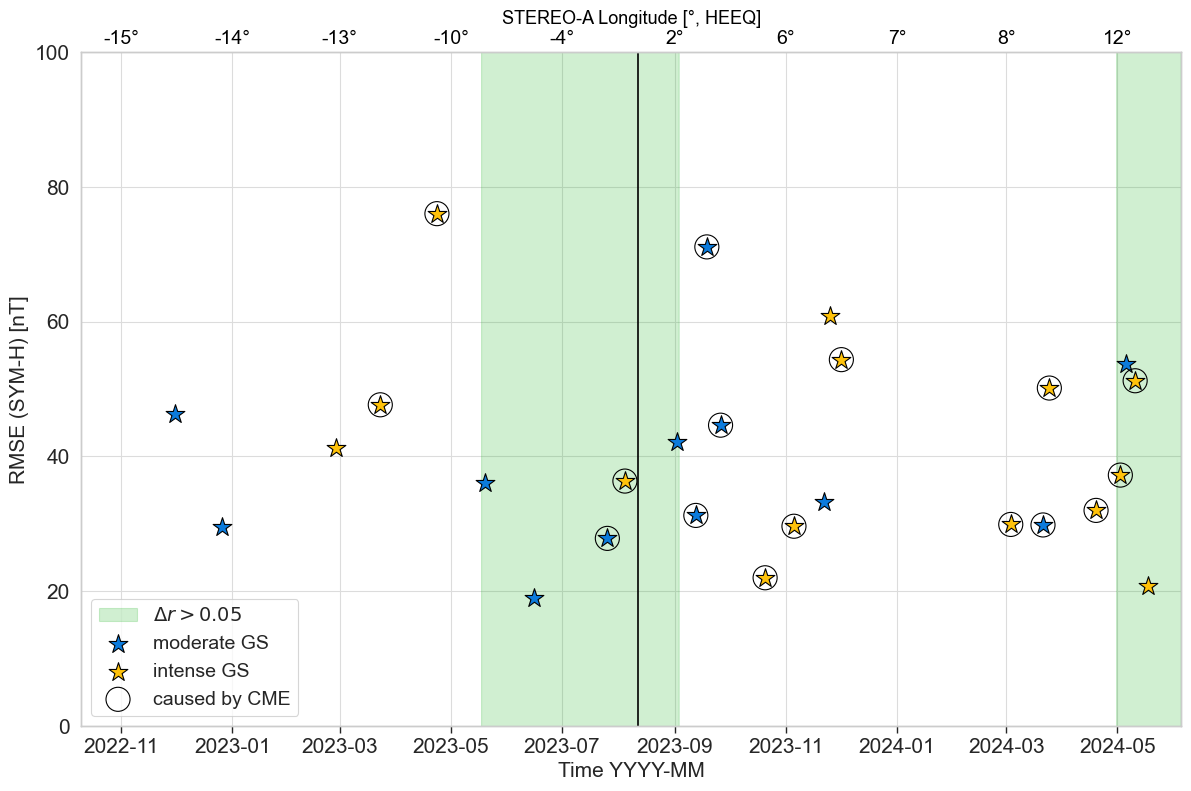

In [42]:
fig, ax1 = plt.subplots(figsize=(12,8), dpi=100)#, gridspec_kw={'height_ratios': [2, 1]})

ax1.fill_between(sc_input_heeq.time, -100, 200, where=delta_r_earth>0.05, color=c4, alpha=0.2, label=r'$\Delta r > 0.05$')
ax1.plot([datetime(2023,8,12),datetime(2023,8,12)], [-5,120], 'k-')
ax1.scatter(time_gs_mod, rmse_true_pos_mod, marker='*', s=200, color=c3, edgecolor='black', label='moderate GS')
#ax1.scatter(time_gs_mod_new, rmse_true_pos_mod_new, marker='*', s=200, color=c3, alpha=0.8, edgecolor='black', label='moderate GS')
#ax1.scatter(time_hit_omni[index_int], rmse_all[index_int], marker='*', s=200, color=c3, edgecolor='black', label='moderate GS')
#ax1.scatter(time_hit_omni[index_mod], rmse_all[index_mod], marker='*', s=200, color=c3, edgecolor='black', label='moderate GS')
ax1.scatter(time_gs_int, rmse_true_pos_int, marker='*', s=200, color=c2, edgecolor='black', label='intense GS')
#ax1.scatter(time_gs_int_new, rmse_true_pos_int_new, marker='*', s=200, color=c2, alpha=0.8, edgecolor='black', label='intense GS')
ax1.scatter(times_gs.start_time[index_cme_gs], rmse_all[index_cme_gs], marker='o', s=300, facecolors='none', edgecolor='black', label='caused by CME')
#ax1.scatter(time_gs_int_new, rmse_true_pos_int_new, marker='*', s=200, color=c3, edgecolor='black', label='intense GS')
#ax1.annotate(str(event_gs_mod), xy=(time_gs_mod,rmse_true_pos_mod))
ax1.plot([datetime(2023,8,12),datetime(2023,8,12)], [-550,0], 'k-')
ax1.set_ylim(0,100)
ax1.set_xlim(datetime(2022,10,10), datetime(2024,6,5))
ax1.set_ylabel('RMSE (SYM-H) [nT]',fontsize=15)
ax1.tick_params('x', labelsize=15)
ax1.tick_params('y', labelsize=15)
ax1.legend(loc='lower left', fontsize=14)
t_float = date2num(sc_input.time)
ax3 = ax1.twiny()
ticks = ax1.get_xticks()
ax3.set_xticks(mdates.num2date(ticks))
ax3.grid(False)
lon_interp = np.interp(ticks, t_float, sc_input_heeq.lon)
ax3.set_xticklabels([f"{L:.0f}°" for L in lon_interp], color=c0, fontsize=14)
ax3.set_xlabel('STEREO-A Longitude [°, HEEQ]', color=c0,fontsize=13)  # we already handled the x-label with ax1
ax3.tick_params(axis='x', length=0)
ax3.set_xlim(ax1.get_xlim())
ax1.set_xlabel('Time YYYY-MM',fontsize=15)

plt.tight_layout()
#plt.savefig('symh_true_positives.pdf')

In [44]:
print(np.mean(rmse_all), np.mean(rmse_all_new)) 
print(np.mean(rmse_true_pos_int), np.mean(rmse_true_pos_int_new))
print(np.mean(rmse_true_pos_mod), np.mean(rmse_true_pos_mod_new))

40.5455965582973 29.86811748112029
42.11000310622681 32.4424952847589
38.72045558571286 26.86467671020857


In [43]:
#for paper (Table 2)
for i in range(len(time_hit_omni)):
    date_time = time_hit_omni[i].strftime("%Y-%m-%dT%H:%MZ")

    print(str(i+1), '&', date_time, '&', round(time_diff[i],1), '&', symh_hit_omni[i], '&', round(symh_diff[i],1), '\\\\')

1 & 2022-11-30T19:19Z & -10.8 & -80.0 & -27.8 \\
2 & 2022-12-27T08:11Z & 9.8 & -73.0 & -20.0 \\
3 & 2023-02-27T12:13Z & -6.6 & -161.0 & 24.5 \\
4 & 2023-03-24T05:22Z & -4.6 & -170.0 & 6.1 \\
5 & 2023-04-24T04:03Z & -7.5 & -233.0 & -27.4 \\
6 & 2023-05-20T07:11Z & -2.3 & -82.0 & -32.0 \\
7 & 2023-06-16T09:32Z & 19.4 & -84.0 & 10.6 \\
8 & 2023-07-26T07:54Z & -2.6 & -67.0 & -24.1 \\
9 & 2023-08-05T05:49Z & -7.2 & -103.0 & -10.6 \\
10 & 2023-09-02T10:20Z & -12.0 & -75.0 & -34.3 \\
11 & 2023-09-12T22:03Z & -1.4 & -84.0 & -20.1 \\
12 & 2023-09-19T02:50Z & -13.4 & -96.0 & -76.0 \\
13 & 2023-09-26T20:12Z & 11.2 & -61.0 & -46.1 \\
14 & 2023-10-21T07:28Z & 1.2 & -108.0 & 9.3 \\
15 & 2023-11-05T16:55Z & -1.0 & -189.0 & 51.7 \\
16 & 2023-11-22T06:43Z & -4.8 & -73.0 & -18.4 \\
17 & 2023-11-25T19:11Z & -2.6 & -109.0 & -68.6 \\
18 & 2023-12-01T13:30Z & -7.1 & -136.0 & -52.3 \\
19 & 2024-03-03T18:06Z & 2.1 & -128.0 & 69.0 \\
20 & 2024-03-21T19:36Z & -5.7 & -81.0 & 21.6 \\
21 & 2024-03-24T16:21Z & -7.3

### Create Frames for Figures 7a and 7b in paper:

In [44]:
def make_frame(k, make_movie=False):
    '''
    loop each frame in multiprocessing
    '''
    

    fig=plt.figure(1, figsize=(19.2,7.8), dpi=100) #full hd
    #fig = plt.figure(figsize=(15,10), dpi=100)
    
    # Grid: 3 rows, 3 columns, with specific placement
    gs = gridspec.GridSpec(3, 3, figure=fig, height_ratios=[0.6, 0.05, 2], width_ratios=[20, 0.3, 2], hspace=0.01, wspace=0.03)

    # Top density (time KDE)
    ax0 = fig.add_subplot(gs[0, :2])

    # Bottom SYM-H time series
    ax1 = fig.add_subplot(gs[2, :2])

    # Right SYM-H KDE
    ax2 = fig.add_subplot(gs[2, -1], sharey=ax1)
    
    
    #fig=plt.figure(1, figsize=(19.2*2,10.8*2), dpi=100) #4k


    frame_time_str=str(mdates.num2date(frame_time_num+k*res_in_days))
    
    time_now=frame_time_num+k*res_in_days
    time_now_date = t_start + timedelta(days=k*res_in_days)
    
    #print(index)
    

    
    #ensemble_at_time_now = time_ensemble[index]
    #error_time = (ensemble_at_time_now-np.median(ensemble_at_time_now))/24./3600

    #print(mdates.num2date(time_now+error_time))
    
    #------------------------------------------------ IN SITU DATA ------------------------------------------------------
  
    #cut data for plot window so faster
    
    if data1['time'][-1] > time_now_date+timedelta(days=days_window):
        dindex1=np.where(data1['time'] > time_now_date-timedelta(days=days_window))[0][0]
        dindex2=np.where(data1['time'] > time_now_date+timedelta(days=days_window))[0][0]
        #use last index   oindex2=np.size(o1)-1
        data=data1[dindex1:dindex2] 
        
    if data_l1['time'][-1] > time_now_date+timedelta(days=days_window):
        lindex1=np.where(data_l1['time'] > time_now_date-timedelta(days=days_window))[0][0]
        lindex2=np.where(data_l1['time'] > time_now_date+timedelta(days=days_window))[0][0]
        #use last index   oindex2=np.size(o1)-1
        l1=data_l1[lindex1:lindex2] 
        
    if omni_input['time'][-1] > time_now_date+timedelta(days=days_window):
        oindex1=np.where(omni_input['time'] > time_now_date-timedelta(days=days_window))[0][0]
        oindex2=np.where(omni_input['time'] > time_now_date+timedelta(days=days_window))[0][0]
        #use last index   oindex2=np.size(o1)-1
        omni=omni_input[oindex1:oindex2] 
        
    index = np.where(data['time']==time_now_date)[0][0]
    current_symh = data['symh'][index]
        
    days_dist = 2
    
    # Compute KDE manually
    std = data['time_err'][index]
    x_vals = np.linspace(-3*std,3*std,100)
    y_vals = norm(loc=time_now, scale=std/24.).pdf(time_now+x_vals/24.)
    #y_fin = y/np.nanmax(y,axis=0)
    
    #kde = gaussian_kde(time_now+error_time)
    #x_vals = np.linspace(time_now - days_window, time_now + days_window, 500)
    #y_vals = kde(x_vals)

    # Normalize to max = 1
    y_vals /= np.nanmax(y_vals)
    
    

    #with sns.axes_style('white', {'axes.edgecolor': 'none'}):
    #ax0 = plt.subplot2grid((3,1), (0,0))
    #sns.kdeplot(time_now+error_time, ax=ax0,  color=c3, linewidth=2, fill=True)
    ax0.fill_between(time_now+x_vals/24., y_vals, color=c3, alpha=0.6)
    ax0.plot(time_now+x_vals/24., y_vals, color=c3, linewidth=2)
    ax0.plot_date([time_now,time_now], [0,2],'--', lw=1., alpha=0.9, color=c0)


    ax0.set_xlim(time_now-days_window,time_now+days_window)
    ax0.set_ylim(0.01,1.01)
    ax0.set_xticklabels([])
    ax0.set_yticklabels([])
    plt.tick_params( axis='x', labelbottom='off')
    #plt.yticks(fontsize=fsize-1)

    
    if np.size(data)>0:
        
        #ax1 = plt.subplot2grid((3,1), (1,0), rowspan=2)
        #ax1.set_ylim(np.min(data['symh'])-20, np.max(data['symh'])+20)
        #ax1.set_xlabel('time [YYYY-Month-DD]', fontsize=16)
        ax1.set_ylabel('SYM-H [nT]', fontsize=15)
        ax1.set_xlim(time_now-days_window,time_now+days_window)
        ax1.xaxis.set_major_formatter( matplotlib.dates.DateFormatter('%Y-%b-%d') )
        ax1.xaxis.set_major_locator(matplotlib.ticker.MultipleLocator(days_dist))
        ax1.xaxis.set_minor_locator(matplotlib.ticker.MultipleLocator(days_dist/6))
        ax1.tick_params(axis='x', labelsize=15)
        ax1.tick_params(axis='y', labelsize=15)

        for i in range(len(times_earth_start)):
            ax1.fill_betweenx([-1000,200], times_earth_start[i], times_earth_end[i], color=c2, alpha=0.1)
            ax1.plot_date([times_earth_start[i],times_earth_start[i]], [-1000,200], '-', color=c2, lw=.8, alpha=.6)
            ax1.plot_date([times_earth_end[i],times_earth_end[i]], [-1000,200], '-', color=c2, lw=.8, alpha=.6)
            
        #for i in range(len(ic)):
         #   ax1.fill_betweenx([-1000,200], ic.icme_start_time.iloc[i], ic.mo_end_time.iloc[i], color=c2, alpha=0.1)
          #  ax1.plot_date([ic.icme_start_time.iloc[i],ic.icme_start_time.iloc[i]], [-1000,200], '-', color=c2, lw=.8, alpha=.6)
           # ax1.plot_date([ic.mo_end_time.iloc[i],ic.mo_end_time.iloc[i]], [-1000,200], '-', color=c2, lw=.8, alpha=.6)
        
        ax1.plot_date(omni['time'],omni['symh'],'-',c=c0,label='SYM-H obs.',linewidth=1)
        ax1.plot_date(l1['time'],l1['symh'],'-',c=c2,label='SYM-H L1',linewidth=1)
        ax1.plot_date(data['time'],data['symh'],'-',c=c3,label='SYM-H STEREO-A',linewidth=1)
        
        ax1.plot_date([time_now-days_window,time_now+days_window], [current_symh,current_symh],'--k', lw=1., alpha=0.6)
        ax1.plot_date([time_now,time_now], [-600,100],'--k', lw=1., alpha=0.6)
        
       
        #ax1.plot(time_false_alarm_l1_all, symh_false_alarm_l1_all, marker='o', mec=c0, ms=8, color=c2, ls=' ')
        #ax1.plot(time_miss_omni_obs_l1, symh_miss_omni_obs_l1,  marker='o', mfc='none', ms=18, color=c0, ls=' ')
        #ax1.plot(time_hit_omni_l1, symh_hit_omni_l1, marker='*', ms=18,  mec=c0, color=c2, ls=' ')
        
        ax1.plot(time_false_alarm, symh_false_alarm, marker='o', ms=8, mec=c0, color=c3, ls=' ')
        ax1.plot(time_hit_omni, symh_hit_omni, marker='o', ms=8, mec=c0, color=c0, ls=' ')
        ax1.plot(time_miss_omni, symh_miss_omni, marker='x', ms=15, color='red', ls=' ')
        ax1.plot(time_hit_sta, symh_hit_sta, marker='*', ms=18,  mec=c0, color=c3, ls=' ')
        
        #ax1.plot(time_false_alarm_sta_l1, symh_false_alarm_sta_l1, marker='o', mfc='none', ms=13, color=c0, ls=' ') 
        #ax1.plot(time_false_alarm_l1_sta, symh_false_alarm_l1_sta, marker='o', mfc='none', ms=13, color=c0, ls=' ') 
        
        ax1.legend(loc='lower left', fontsize=13)
        
        if np.min(omni.symh) < np.min(data['symh']) and  np.min(omni.symh) < np.min(l1['symh']):
            ax1.set_ylim(np.min(omni['symh'])-10,np.max(omni['symh'])+10)
        elif np.min(l1.symh) < np.min(data['symh']) and  np.min(l1.symh) < np.min(omni.symh):
            ax1.set_ylim(np.min(l1['symh'])-10,np.max(omni['symh'])+10)
        elif np.min(data['symh']) < np.min(l1.symh) and  np.min(data['symh']) < np.min(omni.symh):
            ax1.set_ylim(np.min(data['symh'])-10,np.max(omni['symh'])+10)
        
        
     # === 3. SYM-H KDE (right-side panel) ===
    std_symh = data['symh_err'][index]
    x_vals_symh = np.linspace(-3*std_symh,3*std_symh,100)
    y_vals_symh = norm(loc=current_symh, scale=std_symh).pdf(current_symh+x_vals_symh)
    y_vals_symh /= np.nanmax(y_vals_symh, axis=0)
    
    #kde_symh = gaussian_kde(symh_ensemble[index])
    #y_vals_symh = np.linspace(np.min(symh_ensemble[index]), np.max(symh_ensemble[index]), 250)
    #x_vals_symh = kde_symh(y_vals_symh)
    #x_vals_symh /= np.max(x_vals_symh)  # normalize
    
    ax2.plot_date([0,1.01], [current_symh,current_symh],'--k', lw=1., alpha=0.6)
                
    ax2.fill_betweenx(current_symh+x_vals_symh, y_vals_symh, color=c3, alpha=0.6)
    ax2.plot(y_vals_symh, current_symh+x_vals_symh, color=c3, linewidth=2)
    ax2.set_xlim(0.01, 1.01)
    ax2.set_xticklabels([])
    ax2.tick_params(labelleft=False, left=False)
    #ax2.tick_params(axis='y', labelsize=13)
    #ax2.set_yticklabels([])
    #ax2.set_xlabel('Density', fontsize=fsize-1)
    #ax2.tick_params(axis='x', labelsize=fsize-2)
    
    x_pos_text=0.4
    y_pos_text=0.9
    
    plt.figtext(x_pos_text, y_pos_text, frame_time_str[0:4], ha='left', color=c0, fontsize=fsize+6)
    
    plt.figtext(x_pos_text+0.038, y_pos_text, frame_time_str[5:7], ha='left', color=c0, fontsize=fsize+6)
    
    plt.figtext(x_pos_text+0.06, y_pos_text, frame_time_str[8:10], ha='left', color=c0, fontsize=fsize+6)
    
    plt.figtext(x_pos_text+0.09, y_pos_text, frame_time_str[11:13], ha='left', color=c0, fontsize=fsize+6)
    
    plt.figtext(x_pos_text+0.13, y_pos_text, 'UTC', ha='center', color=c0, fontsize=fsize+6)
    
    
    plt.tight_layout()
    
    #plt.show()
    
    if make_movie:
        
        #save figure
        framestr = '%05i' % (k)
        filename='figures/frames/gs_event_9.jpg'  
        #if k==0: print(filename)
        plt.savefig(filename,dpi=200,facecolor=fig.get_facecolor(), edgecolor='none')
        #plt.clf()
        #if close==True: plt.close('all')

        plt.close('all')
        
    else:
        plt.show()


    ########################################### loop end'



In [45]:
plt.close('all')

print('Define settings')

count = 0
format_str = '%Y-%m-%d'  
format_str_minutes = '%Y-%m-%d %H:%M'
date_today_hour = datetime.now().strftime(format_str)

#outputdirectory='output/frames'#+str(date_today_hour)
#animdirectory='output/'
t_start = data1['time'][0]
t_end  = data1['time'][-1]
print(t_start)
#res_in_days=1/72. #every 20min
#res_in_days=1/144. #every 10min
res_in_days=1/1440. # every minute
#res_in_days=1/24. #every hour
#res_in_days=1/48. #every 30min


#make time range to see how much frames are needed 
starttime = t_start #parse_time(t_start)
endtime = t_end #parse_time(t_end)
alltimes = []
while starttime < endtime:
    alltimes.append(starttime)
    starttime += timedelta(days=res_in_days)
k_all=np.size(alltimes)

print('# of frames: ', k_all)

#print(date_today_hour)
days_window=3    #size of in situ timerange

#if os.path.isdir(outputdirectory) == False: os.mkdir(outputdirectory)
#if os.path.isdir(animdirectory) == False: os.mkdir(animdirectory)

print('done')

#positions_plot_directory='results/plots_positions/'
#if os.path.isdir(positions_plot_directory) == False: os.mkdir(positions_plot_directory)

#print(k_all)

#print('done')
#print(mdates.num2date(hc_time_num1))


Define settings
2022-11-11 10:08:00
# of frames:  823680
done


Save kinematics plots and overview plot for current time


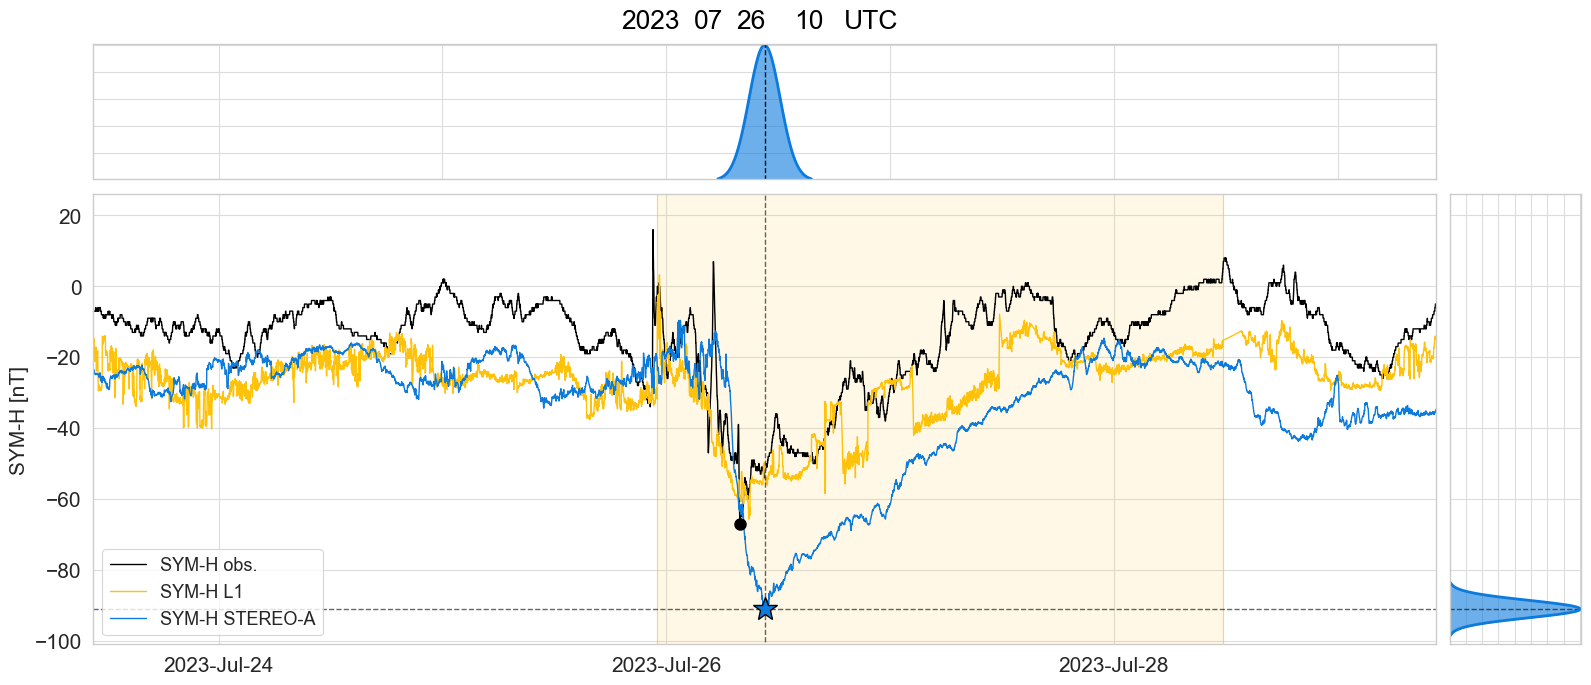

done


In [47]:

print('Save kinematics plots and overview plot for current time')

#%matplotlib inline

start_time=time.time()

#print()
#print('make animation')

#animation start time in matplotlib format

frame_time_num=mdates.date2num(t_start)#parse_time(t_start).plot_date
#frame_time = datetime(2024,3,17,10)

frame_time_num_list = [frame_time_num+k*res_in_days for k in range(k_all)]

dct_hit = [mdates.date2num(time_hit_sta[i])-frame_time_num_list for i in range(len(time_hit_sta))]

k_hit=[]

for i in dct_hit:
    k_hit.append(np.argmin(np.abs(i)))

    
dct_miss = [mdates.date2num(time_miss_omni[i])-frame_time_num_list for i in range(len(time_miss_omni))]

k_miss=[]

for i in dct_miss:
    k_miss.append(np.argmin(np.abs(i)))
    

dct_fa = [mdates.date2num(time_false_alarm[i])-frame_time_num_list for i in range(len(time_false_alarm))]

k_fa=[]

for i in dct_fa:
    k_fa.append(np.argmin(np.abs(i)))

#frame_index = np.where(frame_time_num_list==mdates.date2num(datetime(2024,3,18,16,0)))[0][0]#

fsize=13


#for parker spiral   
theta=np.arange(0,np.deg2rad(180),0.01)

######################## make frames

#for debugging
#don't close plot in make_frame when testing

#plot_kinematics(hc_time_num1, hc_r1, hc_v1)
####################### plot and save frame with todays date and hour 
#make_frame3(k_today[0][0]) 

####################### test animation frames (different frame numbers)
#make_frame2(frame_index)#k_today[0][0])
make_movie=False
make_frame(k_hit[7])#k_today[0][0]) #6000



print('done') #



### Create movie

In [48]:
make_movie=False
if make_movie:
    
    import multiprocessing
    import multiprocess as mp
    matplotlib.use('Agg')

    print('Creating ', k_all,' frames')

    print()

    start_time=time.time()

    #number of processes depends on your machines memory; check with command line "top"
    #how much memory is used by all your processesii
    nr_of_processes_used=3
    print('Using multiprocessing, nr of cores',multiprocessing.cpu_count(), \
          'with nr of processes used: ',nr_of_processes_used)

    #run multiprocessing pool to make all movie frames, depending only on frame number

    pool=mp.get_context('fork').Pool(processes=nr_of_processes_used)

    #pool = mp.Pool(processes=nr_of_processes_used)
    #input=[i for i in range(k_all)]
    input=[i for i in np.arange(1,k_all,1)]
    pool.map(make_frame, input)
    pool.close()
    pool.join()
    #for i in input:
     #   make_frame2(i)

    print('time in min: ',np.round((time.time()-start_time)/60))
    print('plots done, frames saved')


In [49]:
if make_movie:

    ffmpeg_path=''

    os.system(ffmpeg_path+'ffmpeg -r 20 -i figures/frames/pos_anim_%05d.jpg -b 5000k \
        -r 20 figures/frames/symh_forecast.mp4 -y -loglevel warning') 

    print('movie done & saved')